In [1]:
!pip install rdkit-pypi -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.4/29.4 MB 16.0 MB/s eta 0:00:00


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.feature_extraction.text import CountVectorizer
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.listdir('/content/drive/MyDrive')
os.chdir('/content/drive/MyDrive/mtech_project/')
print("Current working directory is: ", os.getcwd())

Mounted at /content/drive
Current working directory is:  /content/drive/MyDrive/mtech_project


In [38]:
data_dir = os.path.join(os.getcwd(), 'data')
src_dir = os.path.join(os.getcwd(), 'src')
fig_dir = os.path.join(data_dir, 'figures')
checkpoint_dir = os.path.join(os.getcwd(), 'checkpoints')
dirs_to_make = [
    data_dir,
    os.path.join(data_dir, 'raw'),
    os.path.join(data_dir, 'processed'),
    os.path.join(data_dir, 'train'),
    os.path.join(data_dir, 'val'),
    os.path.join(data_dir, 'test'),
    src_dir,
    fig_dir,
    checkpoint_dir,
]
for d in dirs_to_make:
    if not os.path.exists(d):
        os.makedirs(d)

In [39]:
final_df = pd.read_csv("/content/drive/MyDrive/mtech_project/Required_data.csv")
final_df.head()

,Compound ID,Uniprot,Smiles,E3 Ligase,Cell Type,DC50 (nM),Dmax (%),POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence
0,5,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MOLT-4,53.0,100.0,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...
1,8,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MOLT-4,93.0,90.0,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...
2,61,P00533,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,VHL,H1975,25.3,90.0,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...
3,70,P00533,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,VHL,H1975,5.9,100.0,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...
4,73,Q9NWZ3,COc1cc2c(OC[C@@H]3CCC(=O)N3)ncc(C#CCCCCCCCCCCC...,VHL,PBMCs,3000.0,50.0,MNKPITPSTYVRCLNVGLIRKLSDFIDPQEGWKKLAVAIKKPSGDD...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...


In [40]:
final_df.shape

(504, 10)

In [41]:
final_df.columns

Index(['Compound ID', 'Uniprot', 'Smiles', 'E3 Ligase', 'Cell Type',
       'DC50 (nM)', 'Dmax (%)', 'POI Sequence', 'E3 Ligase Uniprot',
       'E3 Ligase Sequence'],
      dtype='object')

In [42]:
final_df.describe()

,Compound ID,DC50 (nM),Dmax (%)
count,504.000000,504.000000,504.000000
mean,1428.910714,386.967369,82.096766
std,979.405170,2403.066547,18.598317
min,5.000000,0.010000,10.000000
25%,336.000000,7.175000,74.000000
50%,1588.000000,35.350000,88.205000
75%,2354.250000,161.250000,96.000000
max,3261.000000,50000.000000,100.000000


In [43]:
final_df = final_df.rename(columns={'DC50 (nM)': 'DC50', 'Dmax (%)': 'Dmax'})
final_df.head()

,Compound ID,Uniprot,Smiles,E3 Ligase,Cell Type,DC50,Dmax,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence
0,5,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MOLT-4,53.0,100.0,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...
1,8,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MOLT-4,93.0,90.0,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...
2,61,P00533,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,VHL,H1975,25.3,90.0,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...
3,70,P00533,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,VHL,H1975,5.9,100.0,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...
4,73,Q9NWZ3,COc1cc2c(OC[C@@H]3CCC(=O)N3)ncc(C#CCCCCCCCCCCC...,VHL,PBMCs,3000.0,50.0,MNKPITPSTYVRCLNVGLIRKLSDFIDPQEGWKKLAVAIKKPSGDD...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...


In [44]:
# Convert DC50 to -log10
final_df['pDC50'] = -np.log10(final_df['DC50'] / 1e9)
# final_df["Dmax"] = final_df["Dmax"] / 100

In [45]:
final_df.describe()

,Compound ID,DC50,Dmax,pDC50
count,504.000000,504.000000,504.000000,504.000000
mean,1428.910714,386.967369,82.096766,7.508537
std,979.405170,2403.066547,18.598317,1.051281
min,5.000000,0.010000,10.000000,4.301030
25%,336.000000,7.175000,74.000000,6.792502
50%,1588.000000,35.350000,88.205000,7.451632
75%,2354.250000,161.250000,96.000000,8.144186
max,3261.000000,50000.000000,100.000000,11.000000


In [46]:
# import numpy as np
# import pandas as pd

# def label_activity(row) -> str:
#     """
#     Label a data sample as active or inactive based on pDC50 and Dmax in a DataFrame.

#     Args:
#         row (pd.Series): A row from the DataFrame containing 'pDC50' and 'Dmax'.

#     Returns:
#         str: "active" if conditions are met, "inactive" if not, or np.nan if both are NaN.
#     """
#     pDC50 = row['pDC50']
#     Dmax = row['Dmax']

#     # Check if pDC50 and Dmax are NaN
#     if pd.isna(pDC50) and pd.isna(Dmax):
#         return np.nan

#     # Check conditions for being labeled active
#     if (pd.notna(pDC50) and pDC50 >= 7) or (pd.notna(Dmax) and Dmax >= 60):
#         return "active"

#     return "inactive"


# # df = pd.DataFrame(data)

# # # Calculate pDC50 from DC50 (convert DC50 to pDC50)
# # df['pDC50'] = -np.log10(df['DC50'] * 1e-9)

# # Apply the labeling function to each row to create a new 'Activity' column
# final_df['Activity'] = final_df.apply(label_activity, axis=1)

# # # Show the results
# # print(df[['DC50', 'Dmax', 'pDC50', 'Activity']])

In [47]:
def is_active(DC50: float, Dmax: float, oring=False) -> bool:
    """ Check if a PROTAC is active based on DC50 and Dmax.
    Args:
        DC50(float): DC50 in nM
        Dmax(float): Dmax in %
    Returns:
        bool: True if active, False if inactive, np.nan if either DC50 or Dmax is NaN
    """
    pDC50 = -np.log10(DC50 * 1e-9) if pd.notnull(DC50) else np.nan
    Dmax = Dmax / 100
    if pd.notnull(pDC50):
        if pDC50 < 7.0:
            return False
    if pd.notnull(Dmax):
        if Dmax < 0.8:
            return False
    if oring:
        if pd.notnull(pDC50):
            return True if pDC50 >= 7.0 else False
        elif pd.notnull(Dmax):
            return True if Dmax >= 0.8 else False
        else:
            return np.nan
    else:
        if pd.notnull(pDC50) and pd.notnull(Dmax):
            return True if pDC50 >= 7.0 and Dmax >= 0.8 else False
        else:
            return np.nan

Non-Nan Active: 504


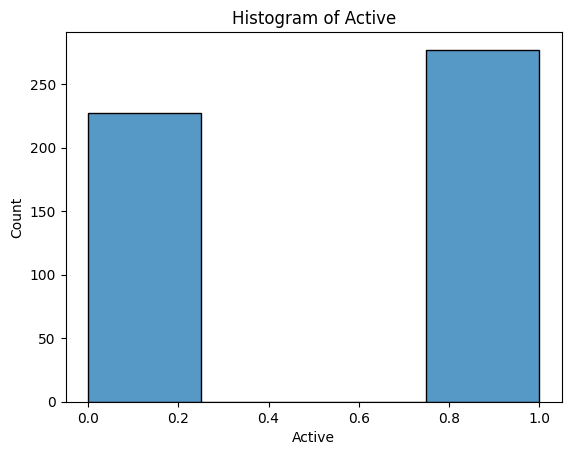

In [48]:
final_df['Active'] = final_df.apply(
    lambda row: is_active(row['DC50'], row['Dmax']),
    axis=1,
)

print(f'Non-Nan Active: {len(final_df[final_df["Active"].notnull()])}')

# Histogram of Active
sns.histplot(data=final_df, x='Active', bins=4)
plt.title('Histogram of Active')
plt.show()

In [49]:
final_df['Activity'] = final_df.apply(
    lambda row: is_active(row['DC50'], row['Dmax'], oring=True), axis=1,
)

plot the columns Active and 'Activity' side by side


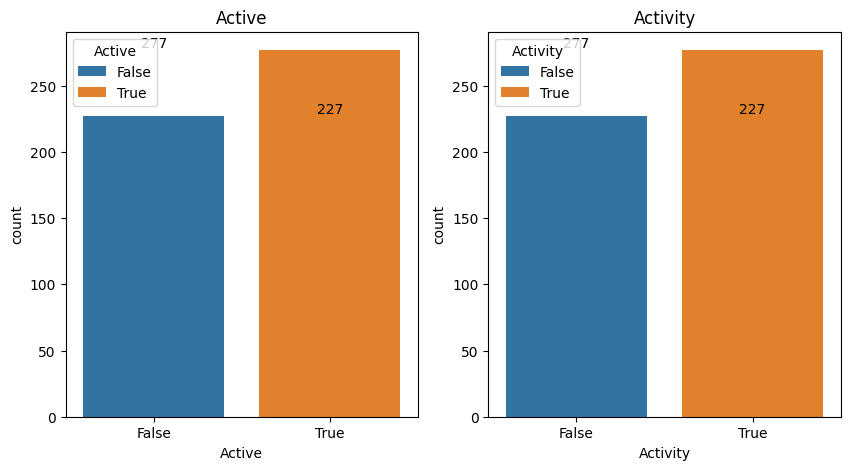

In [50]:
# @title plot the columns Active and 'Activity' side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].set_title('Active')
axes[1].set_title('Activity')
sns.countplot(data=final_df, x='Active', hue = "Active", ax=axes[0])
sns.countplot(data=final_df, x='Activity', hue = "Activity", ax=axes[1])

for i, count in enumerate(final_df['Active'].value_counts()):
    axes[0].text(i, count, count, ha='center', va='bottom')
for i, count in enumerate(final_df['Activity'].value_counts()):
    axes[1].text(i, count, count, ha='center', va='bottom')
plt.show()

In [51]:
final_df.isna().sum()

,0
Compound ID,0
Uniprot,0
Smiles,0
E3 Ligase,0
Cell Type,0
DC50,0
Dmax,0
POI Sequence,0
E3 Ligase Uniprot,0
E3 Ligase Sequence,0


In [52]:
final_df


,Compound ID,Uniprot,Smiles,E3 Ligase,Cell Type,DC50,Dmax,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence,pDC50,Active,Activity
0,5,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MOLT-4,53.0,100.0,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,7.275724,True,True
1,8,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MOLT-4,93.0,90.0,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,7.031517,True,True
2,61,P00533,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,VHL,H1975,25.3,90.0,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,7.596879,True,True
3,70,P00533,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,VHL,H1975,5.9,100.0,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,8.229148,True,True
4,73,Q9NWZ3,COc1cc2c(OC[C@@H]3CCC(=O)N3)ncc(C#CCCCCCCCCCCC...,VHL,PBMCs,3000.0,50.0,MNKPITPSTYVRCLNVGLIRKLSDFIDPQEGWKKLAVAIKKPSGDD...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,5.522879,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,3255,P61964,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MV4;11,3.7,94.0,MATEEKKPETEAARAQPTPSSSATQSKPTPVKPNYALKFTLAGHTK...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,8.431798,True,True
500,3255,P61964,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MIA PaCa-2,45.0,85.0,MATEEKKPETEAARAQPTPSSSATQSKPTPVKPNYALKFTLAGHTK...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,7.346787,True,True
501,3259,Q03111,C[C@H]1CCCN1Cc1nc2ccc(NC(=O)c3ccc4c(cnn4CCCCCC...,CRBN,MV4;11,37.0,95.0,MDNQCTVQVRLELGHRAQLRKKPTTEGFTHDWMVFVRGPEQCDIQH...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,7.431798,True,True
502,3260,Q03111,C[C@H]1CCCN1Cc1nc2ccc(NC(=O)c3ccc4c(cnn4CCCCCC...,CRBN,MV4;11,50.0,68.0,MDNQCTVQVRLELGHRAQLRKKPTTEGFTHDWMVFVRGPEQCDIQH...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,7.301030,False,False


In [53]:
final_df.to_csv('final_df.csv', index=False)


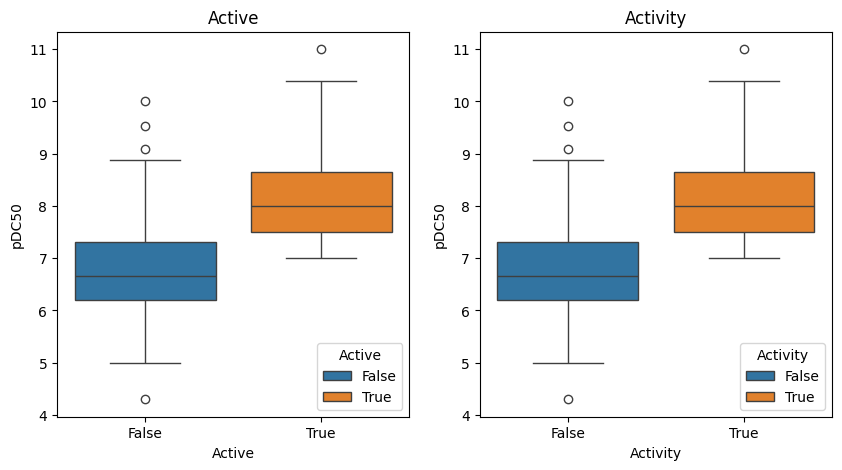

In [54]:
# @title Active vs Activity

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].set_title('Active')
axes[1].set_title('Activity')
sns.boxplot(data=final_df, x='Active', y = "pDC50", hue = "Active", ax=axes[0])
sns.boxplot(data=final_df, x='Activity', y = 'pDC50', hue = "Activity",ax=axes[1])

plt.show()

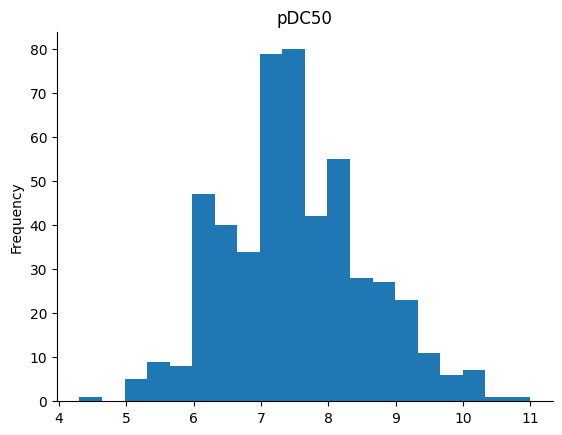

In [55]:
# @title pDC50

from matplotlib import pyplot as plt
final_df['pDC50'].plot(kind='hist', bins=20, title='pDC50')
plt.gca().spines[['top', 'right',]].set_visible(False)

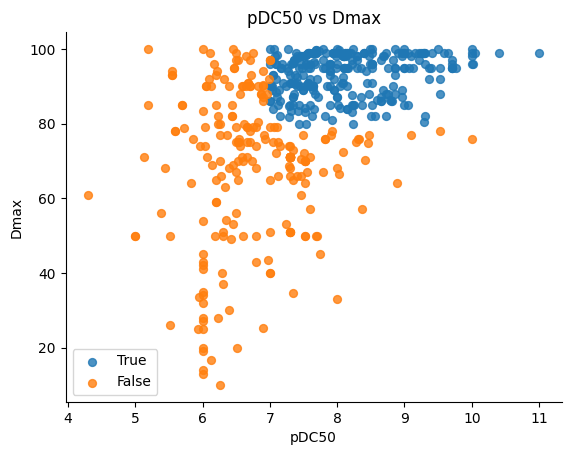

In [56]:
# @title pDC50 vs Dmax

import matplotlib.pyplot as plt

for activity in final_df['Active'].unique():
    subset = final_df[final_df['Active'] == activity]
    plt.scatter(subset['pDC50'], subset['Dmax'], label= activity, s=32, alpha=0.8)

plt.xlabel('pDC50')
plt.ylabel('Dmax')
plt.title('pDC50 vs Dmax')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.legend()
plt.show()

In [57]:
final_df.columns

Index(['Compound ID', 'Uniprot', 'Smiles', 'E3 Ligase', 'Cell Type', 'DC50',
       'Dmax', 'POI Sequence', 'E3 Ligase Uniprot', 'E3 Ligase Sequence',
       'pDC50', 'Active', 'Activity'],
      dtype='object')

In [58]:
final_df_new = final_df[['Uniprot', 'Smiles', 'E3 Ligase', 'Cell Type','POI Sequence', 'E3 Ligase Uniprot', 'E3 Ligase Sequence', 'Activity']]

In [59]:
final_df_new

,Uniprot,Smiles,E3 Ligase,Cell Type,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence,Activity
0,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MOLT-4,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
1,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MOLT-4,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
2,P00533,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,VHL,H1975,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
3,P00533,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,VHL,H1975,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
4,Q9NWZ3,COc1cc2c(OC[C@@H]3CCC(=O)N3)ncc(C#CCCCCCCCCCCC...,VHL,PBMCs,MNKPITPSTYVRCLNVGLIRKLSDFIDPQEGWKKLAVAIKKPSGDD...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,False
...,...,...,...,...,...,...,...,...
499,P61964,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MV4;11,MATEEKKPETEAARAQPTPSSSATQSKPTPVKPNYALKFTLAGHTK...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
500,P61964,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MIA PaCa-2,MATEEKKPETEAARAQPTPSSSATQSKPTPVKPNYALKFTLAGHTK...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True
501,Q03111,C[C@H]1CCCN1Cc1nc2ccc(NC(=O)c3ccc4c(cnn4CCCCCC...,CRBN,MV4;11,MDNQCTVQVRLELGHRAQLRKKPTTEGFTHDWMVFVRGPEQCDIQH...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True
502,Q03111,C[C@H]1CCCN1Cc1nc2ccc(NC(=O)c3ccc4c(cnn4CCCCCC...,CRBN,MV4;11,MDNQCTVQVRLELGHRAQLRKKPTTEGFTHDWMVFVRGPEQCDIQH...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False


In [60]:
final_df_new.isna().sum()

,0
Uniprot,0
Smiles,0
E3 Ligase,0
Cell Type,0
POI Sequence,0
E3 Ligase Uniprot,0
E3 Ligase Sequence,0
Activity,0


In [61]:
final_df_new.dropna(subset=['Activity', "Cell Type"], inplace=True)
final_df_new = final_df_new.reset_index(drop=True)

In [62]:
final_df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Uniprot             504 non-null    object
 1   Smiles              504 non-null    object
 2   E3 Ligase           504 non-null    object
 3   Cell Type           504 non-null    object
 4   POI Sequence        504 non-null    object
 5   E3 Ligase Uniprot   504 non-null    object
 6   E3 Ligase Sequence  504 non-null    object
 7   Activity            504 non-null    bool  
dtypes: bool(1), object(7)
memory usage: 28.2+ KB


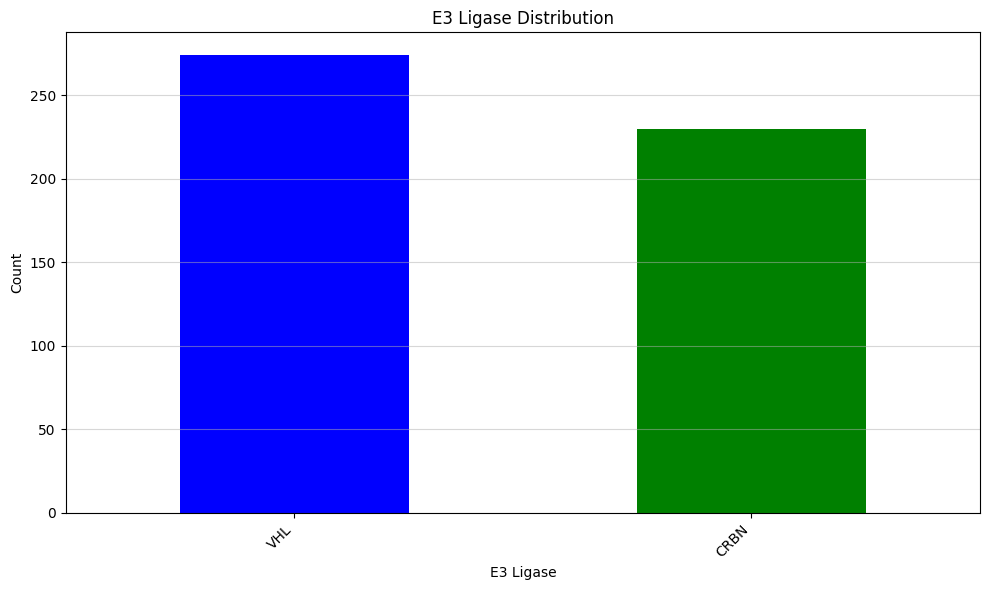

In [63]:
plt.figure(figsize=(10, 6))
e3_counts = final_df_new["E3 Ligase"].value_counts()

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']

e3_counts.plot(kind='bar', color=colors[:len(e3_counts)])

plt.title('E3 Ligase Distribution')
plt.xlabel('E3 Ligase')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

In [64]:
final_df_new["E3 Ligase"].value_counts()

,count
E3 Ligase,
VHL,274
CRBN,230


In [65]:
final_df_new["Activity"].value_counts()

,count
Activity,
True,277
False,227


In [66]:
final_df_new["Cell Type"].value_counts()

,count
Cell Type,
VCaP,52
HeLa,32
HEK293T,27
LNCaP,27
Panc02.13,23
...,...
HCC1937,1
Huh7,1
MDA-MB-468,1


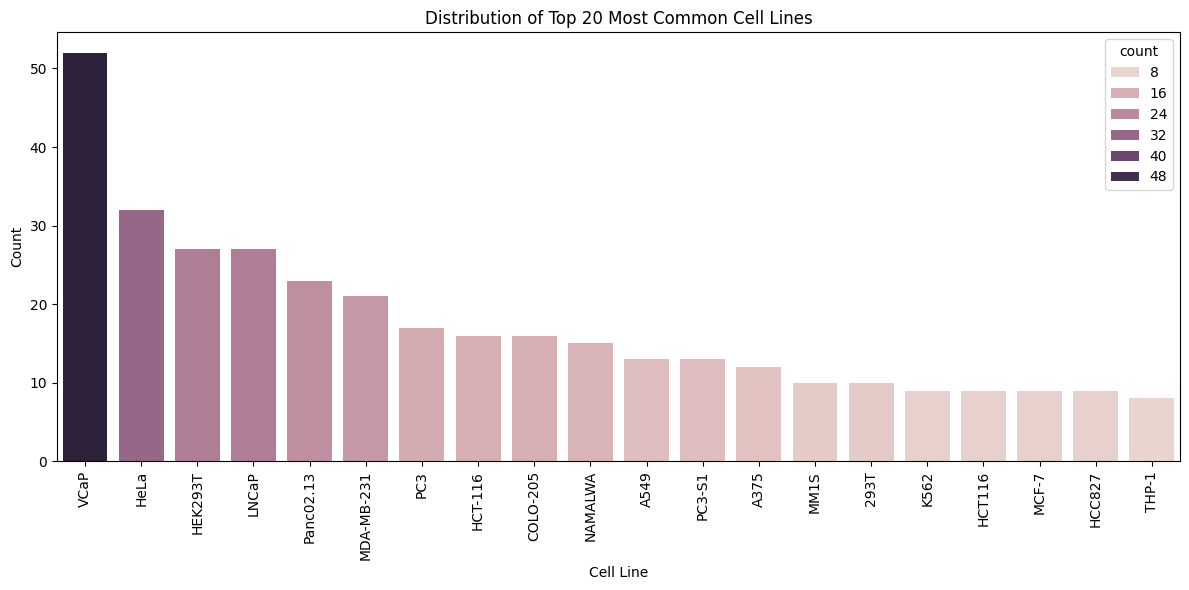

In [67]:
cell_line_counts = final_df_new['Cell Type'].value_counts()

top_20_cell_lines = cell_line_counts.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_cell_lines.index, hue = top_20_cell_lines, y=top_20_cell_lines.values)
plt.xticks(rotation=90)
plt.xlabel('Cell Line')
plt.ylabel('Count')
plt.title('Distribution of Top 20 Most Common Cell Lines')
plt.tight_layout()
plt.show()

In [68]:
cell_lines = final_df_new["Cell Type"].unique()
cell_lines

array(['MOLT-4', 'H1975', 'PBMCs', 'Hs578t', 'HCC827', 'MOLM14',
       'Panc02.13', 'Human THP-1 monocytes', 'MCF-7 breast cancer cells',
       'NAMALWA', 'MV-4-11', 'LNCaP', '22Rv1', 'H661', 'VCaP', 'THP1',
       'PC3', 'hela', 'K562', 'U251', 'MM1S', 'MOLT4', 'MCF-7', 'Hella',
       'HEK293T', 'WI38 platelets', 'HeLa', 'NCI-H2030', 'SW1573',
       'MDA-MB-231', 'RS4;11', 'A549', 'Huh7', 'RI-1', 'T47D', 'VCaP AR+',
       'HCT116', 'Ramos', 'THP-1', 'OVCAR8', 'H3255', 'XLA', 'RS4; 11',
       'platelets', 'Panc Tu-I', 'DB', 'HEK293', 'A375', 'Mouse 4935',
       'PC9', 'Primary Cardiomyocytes', 'WI38', 'Mino', 'MCF7', 'HLE',
       'HuH-7', 'SNU-423', 'HUH-1', 'HepG2', 'SK-Hep-1', 'Hep3B2.1-7',
       'SNU-387', 'HLF', 'SNU-398', 'HUCCT1', 'NCI-H23', 'NCI-H358',
       'MIA PaCa-2', 'HCC1937', '22RV1', 'MDA-MB-468', 'PC-3',
       'MDA-MB-436', 'Capan-1', 'SW620', 'PC3-S1', 'EOL-1', 'MM.1S',
       'H1666', 'CAL-12T', 'SK-MEL-246', 'SK-MEL-28', 'SR', 'COLO-205',
       'HCT-116',

In [69]:
final_df_new.shape

(504, 8)

Train Test val Split

Different ways to split dataset
1. Stratified Split

2. Scaffold Split

3. Cluster Split

Note: Before applying cluster split we need to find the best fingerprints through GridSearchCV

1. Stratified Split
Ensures that the proportion of different classes in the training and testing sets is similar to the original dataset.
Useful when dealing with imbalanced datasets to ensure that each class is represented proportionally.

In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split

def stratified_split(df, stratify_col, train_size=0.7, val_size=0.2, test_size=0.1, random_state=42):

    assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "The sum of train, val, and test sizes must be 1"

    df_train_val, df_test = train_test_split(
        df, test_size=test_size, random_state=random_state, stratify=df[stratify_col]
    )

    relative_val_size = val_size / (train_size + val_size)
    df_train, df_val = train_test_split(
        df_train_val, test_size=relative_val_size, random_state=random_state, stratify=df_train_val[stratify_col]
    )

    return df_train, df_val, df_test

train_df, val_df, test_df = stratified_split(final_df_new, stratify_col='Activity')

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 352
Validation size: 101
Test size: 51


In [71]:
train_df.to_csv(os.path.join(data_dir, 'train', 'stratified_train_data.csv'), index=False)
val_df.to_csv(os.path.join(data_dir, 'val', 'stratified_val_data.csv'), index=False)
test_df.to_csv(os.path.join(data_dir, 'test', 'stratified_test_data.csv'), index=False)

In [72]:
train_df["Activity"].value_counts()

,count
Activity,
True,193
False,159


In [73]:
val_df["Activity"].value_counts()

,count
Activity,
True,56
False,45


2. Scaffold Split
Splits the dataset based on molecular scaffolds, ensuring that the same scaffold does not appear in both training and testing sets.
Used to test the model's ability to generalize to novel chemical structures.

In [74]:
!pip install rdkit-pypi -q

In [75]:
import os
import pandas as pd
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold

Bemis-Murcko scaffold
It represents the core structure of a compound by simplifying and removing side chains and substituents, highlighting the essential connections and rings within the molecule.
Purpose: It helps in the identification of chemical scaffolds that may serve as templates for drug design, enabling researchers to understand the relationship between structure and biological activity.

In [76]:
# Bemis-Murcko scaffold
def get_scaffold(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)

def scaffold_split(df, smiles_col, train_size=0.7, val_size=0.2, test_size=0.1, random_state=42):
    assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "The sum of train, val, and test sizes must be 1"

    df['scaffold'] = df[smiles_col].apply(get_scaffold)

    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    scaffolds = df['scaffold'].unique()

    train_cutoff = int(len(scaffolds) * train_size)
    val_cutoff = int(len(scaffolds) * (train_size + val_size))

    train_scaffolds = scaffolds[:train_cutoff]
    val_scaffolds = scaffolds[train_cutoff:val_cutoff]
    test_scaffolds = scaffolds[val_cutoff:]

    train_df = df[df['scaffold'].isin(train_scaffolds)]
    val_df = df[df['scaffold'].isin(val_scaffolds)]
    test_df = df[df['scaffold'].isin(test_scaffolds)]

    train_df = train_df.drop(columns=['scaffold'])
    val_df = val_df.drop(columns=['scaffold'])
    test_df = test_df.drop(columns=['scaffold'])

    return train_df, val_df, test_df

train_df, val_df, test_df = scaffold_split(final_df_new, smiles_col='Smiles')


In [77]:
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 396
Validation size: 77
Test size: 31


In [79]:
train_df.to_csv(os.path.join(data_dir, 'train', 'scaffold_train_data.csv'), index=False)
val_df.to_csv(os.path.join(data_dir, 'val', 'scaffold_val_data.csv'), index=False)
test_df.to_csv(os.path.join(data_dir, 'test', 'scaffold_test_data.csv'), index=False)

In [80]:
train_df['Activity'].value_counts()

,count
Activity,
True,220
False,176


In [81]:
final_df_new.columns

Index(['Uniprot', 'Smiles', 'E3 Ligase', 'Cell Type', 'POI Sequence',
       'E3 Ligase Uniprot', 'E3 Ligase Sequence', 'Activity', 'scaffold'],
      dtype='object')

In [82]:
final_df_new.to_csv(os.path.join(data_dir, 'processed', 'final_df_new.csv'), index=False)

In [83]:
df = pd.read_csv(os.path.join(data_dir, 'processed', 'final_df_new.csv'))
df.head()

,Uniprot,Smiles,E3 Ligase,Cell Type,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence,Activity,scaffold
0,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MOLT-4,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,O=C(CCCCCC(=O)N1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O...
1,Q07817,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MOLT-4,MSQSNRELVVDFLSYKLSQKGYSWSQFSDVEENRTEAPEGTESEME...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,O=C(CCCCCN1CCN(CCC(CSc2ccccc2)Nc2ccc(S(=O)(=O)...
2,P00533,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,VHL,H1975,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,O=C(CCCCCCCCCCCN1CCN(c2ccc(Nc3ncc4ccc(=O)n(-c5...
3,P00533,C=CC(=O)Nc1cccc(-n2c(=O)cc(C)c3cnc(Nc4ccc(N5CC...,VHL,H1975,MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,O=C(CCCCCN1CCN(c2ccc(Nc3ncc4ccc(=O)n(-c5ccccc5...
4,Q9NWZ3,COc1cc2c(OC[C@@H]3CCC(=O)N3)ncc(C#CCCCCCCCCCCC...,VHL,PBMCs,MNKPITPSTYVRCLNVGLIRKLSDFIDPQEGWKKLAVAIKKPSGDD...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,False,O=C(CCCCCCCCCCC#Cc1cnc(OCC2CCC(=O)N2)c2ccccc12...


3. Cluster Split
Ensure that all examples of a particular cluster are either in the training set or the validation set, but not both.
Purpose: To enhance model accuracy and generalizability

In [84]:
import os
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

In [85]:
# @title Compute Morgan fingerprints
def compute_fingerprints(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=2048)
    return fp

In [86]:
df['fingerprints'] = df['Smiles'].apply(compute_fingerprints)
df = df.dropna(subset=['fingerprints'])

In [87]:
fingerprints = list(df['fingerprints'].apply(lambda x: list(x)))

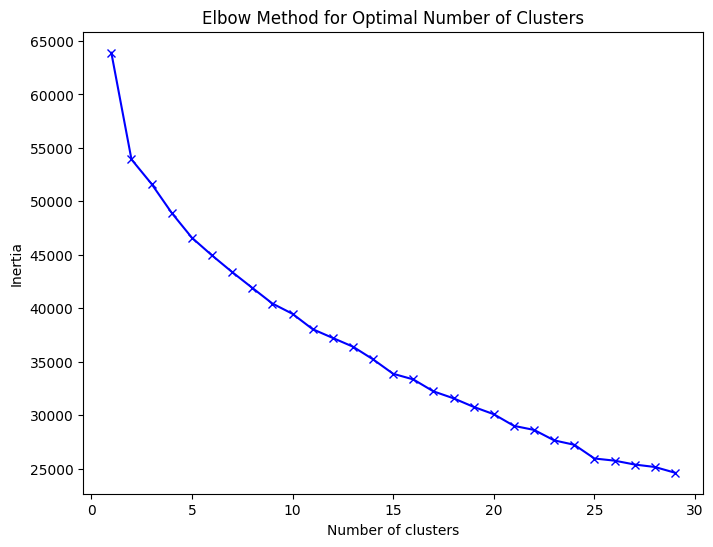

In [88]:
# @title Elbow method to find the optimal number of clusters
inertia = []
K = range(1, 30)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state= 1102)
    kmeans.fit(fingerprints)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

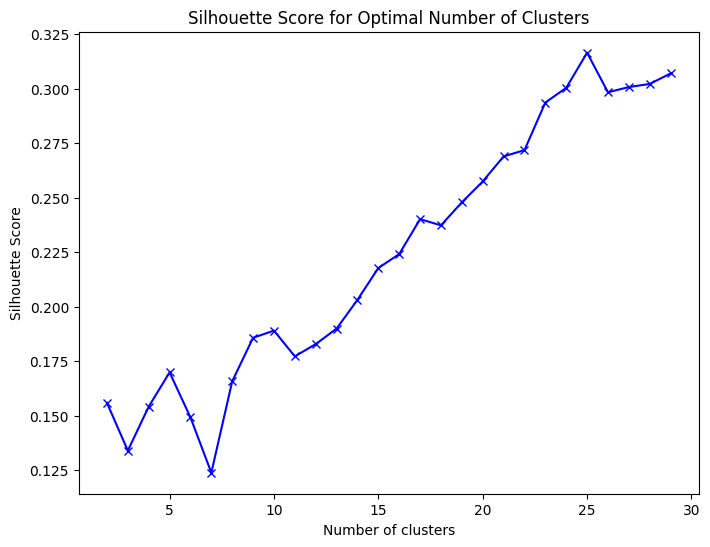

In [89]:
# @title Silhoutte Scores

from sklearn.metrics import silhouette_score

silhouette_scores = []
K = range(2, 30)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=1102)
    kmeans.fit(fingerprints)
    score = silhouette_score(fingerprints, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 6))
plt.plot(K, silhouette_scores, 'bx-')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal Number of Clusters')
plt.show()

In [90]:
# @title Clustering
n_clusters = 20 #<-- we have created 20 clusters
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['cluster'] = kmeans.fit_predict(fingerprints)

In [91]:
from sklearn.manifold import TSNE

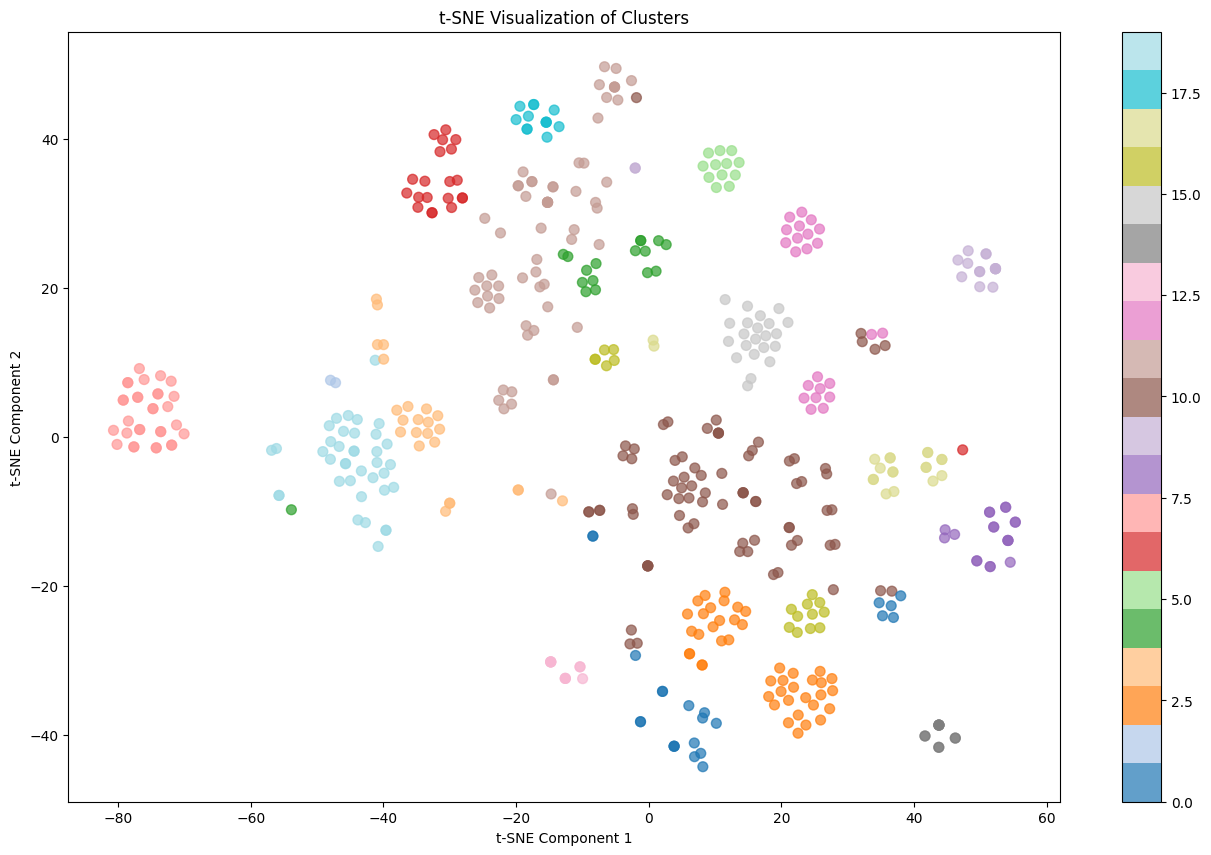

In [92]:
# @title Visualization of Clusters
tsne = TSNE(n_components=2, random_state=42)

fingerprints_array = np.array(fingerprints)
tsne_results = tsne.fit_transform(fingerprints_array)

df['tsne-2d-one'] = tsne_results[:, 0]
df['tsne-2d-two'] = tsne_results[:, 1]

# Plot the clusters
plt.figure(figsize=(16, 10))
plt.scatter(
    x=df['tsne-2d-one'],
    y=df['tsne-2d-two'],
    c=df['cluster'],
    cmap='tab20',
    s=50,
    alpha=0.7,
)
plt.colorbar()
plt.title("t-SNE Visualization of Clusters")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

In [93]:
# Split the dataset based on clusters
train_clusters, test_clusters = train_test_split(df['cluster'].unique(), test_size=0.1, random_state=42)
train_clusters, val_clusters = train_test_split(train_clusters, test_size=0.2222, random_state=42)  # 0.2222 * 0.9 ≈ 0.2

In [94]:
train_df = df[df['cluster'].isin(train_clusters)]
val_df = df[df['cluster'].isin(val_clusters)]
test_df = df[df['cluster'].isin(test_clusters)]

In [95]:
train_df.to_csv(os.path.join(data_dir, 'train', 'cluster_train_data.csv'), index=False)
val_df.to_csv(os.path.join(data_dir, 'val', 'cluster_val_data.csv'), index=False)
test_df.to_csv(os.path.join(data_dir, 'test', 'cluster_test_data.csv'), index=False)

In [96]:
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

Train size: 341
Validation size: 135
Test size: 28


In [97]:
train_df

,Uniprot,Smiles,E3 Ligase,Cell Type,POI Sequence,E3 Ligase Uniprot,E3 Ligase Sequence,Activity,scaffold,fingerprints,cluster,tsne-2d-one,tsne-2d-two
7,Q16288,CC[C@H](C)[C@H](N)c1cn([C@@H](Cc2ccc(O)cc2)C(=...,CRBN,Hs578t,MDVSLCPAKCSFWRIFLLGSVWLDYVGSVLACPANCVCSKTEINCR...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False,O=C1CCC(N2C(=O)c3cccc(NC(=O)CCCCCn4cc(COCCOCCO...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",11,-22.335459,27.383537
10,Q06187,Cc1cc(C2CC2)cc2ccn(-c3cccc(-c4cc(Nc5ccc(N6CCN(...,CRBN,MOLM14,MAAVILESIFLKRSQQKKKTSPLNFKKRLFLLTVHKLSYYEYDFER...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True,O=C(CNc1cccc2c1C(=O)N(C1CCC(=O)NC1=O)C2=O)NCCO...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, ...",11,-16.206430,28.031658
11,Q9UHD2,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,Panc02.13,MQSTSNHLWLLSDILGQGATANVFRGRHKKTGDLFAIKVFNNISFL...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,False,O=C(COCCCOCCCCCOc1ccc(Nc2nccc(NCCCNC(=O)C3CCC3...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ...",2,23.684319,-35.023945
12,Q9UHD2,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,Panc02.13,MQSTSNHLWLLSDILGQGATANVFRGRHKKTGDLFAIKVFNNISFL...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,O=C(COCCOCCOCCCCOc1ccc(Nc2nccc(NCCCNC(=O)C3CCC...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ...",2,25.980650,-34.645428
13,Q9UHD2,Cc1ncsc1-c1ccc(CNC(=O)[C@@H]2C[C@@H](O)CN2C(=O...,VHL,Panc02.13,MQSTSNHLWLLSDILGQGATANVFRGRHKKTGDLFAIKVFNNISFL...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,False,O=C(COCCOCCOCCOCCOc1ccc(Nc2nccc(NCCCNC(=O)C3CC...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, ...",2,26.035875,-33.010788
...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,P61964,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MV4;11,MATEEKKPETEAARAQPTPSSSATQSKPTPVKPNYALKFTLAGHTK...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,O=C(CNC(=O)c1cccc(-c2ccc(N3CCNCC3)c(NC(=O)c3cc...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",0,-1.223929,-38.250942
500,P61964,Cc1ncsc1-c1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)...,VHL,MIA PaCa-2,MATEEKKPETEAARAQPTPSSSATQSKPTPVKPNYALKFTLAGHTK...,P40337,MPRRAENWDEAEVGAEEAGVEEYGPEEDGGEESGAEESGPEESGPE...,True,O=C(CNC(=O)c1cccc(-c2ccc(N3CCNCC3)c(NC(=O)c3cc...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...",0,-1.223929,-38.250942
501,Q03111,C[C@H]1CCCN1Cc1nc2ccc(NC(=O)c3ccc4c(cnn4CCCCCC...,CRBN,MV4;11,MDNQCTVQVRLELGHRAQLRKKPTTEGFTHDWMVFVRGPEQCDIQH...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,True,O=C1CCC(N2C(=O)c3cccc(NCCCCCCCCn4ncc5cc(C(=O)N...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",11,-17.303020,14.292828
502,Q03111,C[C@H]1CCCN1Cc1nc2ccc(NC(=O)c3ccc4c(cnn4CCCCCC...,CRBN,MV4;11,MDNQCTVQVRLELGHRAQLRKKPTTEGFTHDWMVFVRGPEQCDIQH...,Q96SW2,MAGEGDQQDAAHNMGNHLPLLPAESEEEDEMEVEDQDSKEAKKPNI...,False,O=C1CCC(N2C(=O)c3cccc(NCCCCCCn4ncc5cc(C(=O)Nc6...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",11,-18.244940,13.655479


In [98]:
train_df["cluster"].unique()

array([11,  2,  6,  8, 13,  4, 16, 15,  0, 14, 19, 12,  1,  7],
      dtype=int32)